The point of this notebook is to:
- determine the length of time it will take to use libraries to process text detection.
- test optimisation strategies.

Aims/requirements:
- All profanity should be filtered out, particularly those in subtitles. Starred words should also be removed.
- Profanity filtering should only take ~1 second per second of footage. This ensures an hour video can be filtered in ~1 hour
- Ideally, this process should take < 0.5 seconds per second of footage.

In [4]:
## Imports and global constants
import cv2
import easyocr, pytesseract, paddleocr
import time
import numpy as np

video_path = "../data/raw/example1.mp4"

/home/ananth/repos/video-content-filter/.venv/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
/home/ananth/repos/video-content-filter/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.


Load the profanity file

In [19]:
# Load profanity
profanity_set = set()
profanity_file_path = "../src/content_filter/config/profanity_words.txt"
with open(profanity_file_path, "r", encoding="utf-8") as f:
    for line in f:
        word = line.strip().lower()
        profanity_set.add(word)

def contains_profanity(text):
    words = text.lower().split()
    return any(word.strip(".,!?") in profanity_set for word in words)

Define a function for benchmarking EasyOCR

In [30]:
def run_easy_ocr_on_image(image_data):
    """
    Run EasyOCR on one image and return detected text and time taken.
    """
    if not hasattr(run_easy_ocr_on_image, "_reader"):
        run_easy_ocr_on_image._reader = easyocr.Reader(['en'], quantize=True)

    t0 = time.time()
    results = run_easy_ocr_on_image._reader.readtext(image_data)
    dt = time.time() - t0

    texts = [text for (_, text, _) in results]
    return texts, dt


def run_ocr_video_test(duration, ocr_fn):
    """
    Run an OCR function over frames from the video for `duration` seconds.
    ocr_fn should accept image data and return (texts, dt).
    """
    cap = cv2.VideoCapture(video_path)

    fps = cap.get(cv2.CAP_PROP_FPS)
    print(f"FPS: {fps}")

    frame_count = 0
    max_frames = int(fps * duration)

    all_texts = []
    total_ocr_time = 0.0

    t0 = time.time()
    while cap.isOpened() and frame_count < max_frames:
        ret, frame = cap.read()
        if not ret:
            break

        texts, dt = ocr_fn(frame)
        all_texts.append(texts)
        total_ocr_time += dt

        frame_count += 1

    total_wall_time = time.time() - t0
    cap.release()
    cv2.destroyAllWindows()

    return all_texts, total_wall_time, total_ocr_time

def display_ocr_test_results(duration, all_texts, total_ocr_time, total_wall_time=None):
    if total_wall_time is not None:
        print(f"It took: {total_wall_time:.2f} seconds to process all of the footage")
    print(f"Pure OCR time per second of footage: {(total_ocr_time/duration):.2f} seconds")
    print(f"Detected text items: {sum(map(lambda ts: len(ts), all_texts))}")
    print("Detected texts:")
    if len(all_texts) == 1:
        for text in all_texts[0]:
            print(f"- {text}")
    else:
        for i in range(len(all_texts)):
            print(f"-  Frame {i}: {all_texts[i]}")

In [ ]:
# duration = 0.3
# texts, wall_dt, ocr_dt = run_ocr_test(duration, run_easy_ocr_on_image)

In [22]:
# display_ocr_test_results(duration, texts, ocr_dt, wall_dt)

#### Findings for naive method using EasyOCR on CPU:
- Time taken per second of footage: 190-200s
- <3 minutes per second of footage is WAY too much time.
- Cannot use GPU as the project should run locally on a machine.

In [ ]:
### Trying Tesseract ###
def run_tesseract_ocr_on_image(image_data):
    """
    Use Tesseract OCR to extract all text and bounding boxes from an image.
    """
    # Convert to grayscale for better OCR accuracy
    if len(image_data.shape) == 3:
        gray = cv2.cvtColor(image_data, cv2.COLOR_BGR2GRAY)
    else:
        gray = image_data

    t0 = time.time()
    data = pytesseract.image_to_data(gray, output_type=pytesseract.Output.DICT)
    dt = time.time() - t0

    texts = []
    num_boxes = len(data["text"])
    for i in range(num_boxes):
        text = data["text"][i].strip()
        if text:
            texts.append(text)

    return texts, dt

def run_tesseract_ocr(seconds, output_path):
    cap = cv2.VideoCapture(video_path)

    frame_count = 0
    profanity_boxes = []
    all_texts = []

    fps = cap.get(cv2.CAP_PROP_FPS)
    max_frames = int(fps * seconds)

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter.fourcc('m', 'p', '4', 'v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    t0 = time.time()
    while frame_count < max_frames:
        ret, frame = cap.read()
        if not ret:
            break

        texts, _ = run_tesseract_ocr_on_image(frame)
        all_texts.extend(texts)

        # Get detailed OCR data for profanity boxing
        data = pytesseract.image_to_data(frame, output_type=pytesseract.Output.DICT)
        n_boxes = len(data["text"])

        for i in range(n_boxes):
            word = data["text"][i]
            conf = int(data["conf"][i])

            if conf > 60 and contains_profanity(word):
                x = data["left"][i]
                y = data["top"][i]
                w = data["width"][i]
                h = data["height"][i]

                profanity_boxes.append((frame_count, (x, y, w, h)))
                cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 0, 255), 2)

        frame_count += 1
        out.write(frame)

    dt = time.time() - t0
    cap.release()
    out.release()
    cv2.destroyAllWindows()

    return all_texts, dt


In [24]:
# dt, _ = run_tesseract_ocr(3, "../data/processed/censored_text.mp4")

In [25]:
# print(f"It took: {dt}")
# print(f"Time taken per second of footage: {(dt)/3 :.2f}s")

#### Tesseract naive findings
- Time taken per second of footage: 8.85s on average
- Still not fast enough: a 1 hour video will take 9 hours to filter, which is still too long.
- Need to judge accuracy

##### Testing quality of approaches: naive
In theory, the naive approach should be the most accurate as we are running the OCR every frame.

In [ ]:
# image_path = "../data/samples/Image1.png" 

# image = cv2.imread(image_path)
# assert image is not None, f"Could not load image from: {image_path}"

# texts, dt = get_text_on_image(image)

# print(f"Found {len(texts)} text region(s) in {dt:.4f}s:\n")
# for t in texts:
#     print(f"  {t!r}")

There were many more text regions that were missed, including a subtitle region, which contained large text. Tesseract OCR on its own is not accurate enough for the project. TesseractOCR was built for text recognition in documents, not for text with messy backgrounds. The same text was detected when detecting by character instead, so no performance improvement there.<br>
We need to use a more powerful model but on a smaller area of the image. 

The main models for scene text detection are PaddleOCR (optimised for CPU) and EasyOCR (optimised for GPU).<br>
PaddleOCR is estimated to give a ~3-4x speed up on CPU, so I will test its speed and performance. Also worth testing EasyOCR performance.

In [27]:
def run_paddle_ocr_test(image_path):
    """
    Run PaddleOCR on the given image data and return detected text and time taken.
    """
    paddle_ocr = paddleocr.PaddleOCR(lang='en')
    
    t0 = time.time()
    results = paddle_ocr.predict(image_path)
    dt = time.time() - t0

    texts = []
    if results and results[0]:
        for line in results[0]:
            text, confidence = line[1]
            texts.append(text)

    return texts, dt

# image_path = "../data/samples/Image1.png"
# image = cv2.imread(image_path)
# assert image is not None, f"Could not load image from: {image_path}"

# texts, dt = run_paddle_ocr_test(image)
# print(f"Time taken: {dt:.4f}s")
# print(f"Detected {len(texts)} text region(s):")
# for t in texts:
#     print(f"  {t!r}")


Unfortunately, PaddleOCR is having many issues despite for re-installing it. I will use EasyOCR for now with heavy optimisations due to time I have left to spend on this.

In [28]:
image_path = "../data/samples/Image3.png"
image = cv2.imread(image_path)
assert image is not None, f"Could not load image from: {image_path}"

texts, dt = run_easy_ocr_on_image(image)
print(f"Time taken: {dt:.4f}s")
print(f"Detected {len(texts)} text region(s):")
for t in texts:
    print(f"- {t!r}")


Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Time taken: 7.2283s
Detected 7 text region(s):
- 'subgoal17,005/18,000'
- 'btch'
- 'BadboyHalo'
- 'substoday638'
- 'whatever you'
- 'is the word_'
- 'put'


##### Image 1
Detected 9 text region(s):
- 'Lange Chest'
- 'subgoal:16,994/18,000'
- 'Inventony'
- '29_'
- '12'
- 'substoday 610'
- 'veah i saw vou had'
- '00.00.22'
- '00.03.43'

##### Image 2
Detected 5 text region(s):
- 'subgoal; 16,994F'
- '18,955'
- 'subs'
- 'do-you wanna know the nickname'
- '00.00.39'

EasyOCR is good at detecting and generally recognising all the text. There are some errors, such as "Inventony" as opposed to "Inventory", and "Lange" instead of "Large". The mistakes come from when text is blurrier or smaller. The rest of the text detected is generally correct and by-in-large nothing was missed. It reads subtitles pretty much perfectly, which is the most important text to read.

## Improvements to consider
The main time optimisations are:
- only running EasyOCR on a pre-defined "subtitles region" and only running it when the transcription detects swearing. This will reduce the number of calls to EasyOCR significantly.
- Detecting text on the remaining screen using a more lightweight text detector every couple of frames. EasyOCR will then be called if text is detected.
- Reducing image resolution.

The main performance optimisations are:
- Increasing contrast to make text predictions more accurate/reliable

The other things I need to consider:
- Profanity filtering not as simple as checking if detected text is in profanity list. Need to account for starred words, slight inaccuracies in detection, etc.

In [ ]:
def run_easy_ocr_on_image_grayscale(image_data):
    """
    Run EasyOCR on one image and return detected text and time taken.
    Now we will include optimisations to improve accuracy and see how it affects performance.
    """
    if not hasattr(run_easy_ocr_on_image, "_reader"):
        run_easy_ocr_on_image._reader = easyocr.Reader(['en'], quantize=True)

    t0 = time.time()
    gray = cv2.cvtColor(image_data, cv2.COLOR_BGR2GRAY)
    
    # histogram equalization
    equ = cv2.equalizeHist(gray)

    # manual thresholding
    th2 = 0 # this threshold might vary!
    equ[equ>=th2] = 255
    equ[equ<th2]  = 0

    # Now apply the OCR on the processed image
    results = run_easy_ocr_on_image._reader.readtext(gray)
    dt = time.time() - t0

    texts = [text for (_, text, _) in results]
    return texts, dt

image_path = "../data/samples/Image3.png"
image = cv2.imread(image_path)
texts, dt = run_easy_ocr_on_image(image)
textsGray, dtGray = run_easy_ocr_on_image_grayscale(image)

/home/ananth/repos/video-content-filter/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [85]:
display_ocr_test_results(1.0/30.0, [texts], dt)
print("\nWith pre-processing:")
display_ocr_test_results(1.0/30.0, [textsGray], dtGray) 

Pure OCR time per second of footage: 69.98 seconds
Detected text items: 7
Detected texts:
- subgoal: 17,005/18,000
- ten
- BadboyHalo
- subs today 638
- whatever you
- is the word_
- put

With pre-processing:
Pure OCR time per second of footage: 99.48 seconds
Detected text items: 7
Detected texts:
- subgoal: 17,005/18,000
- ten
- BadboyHalo
- subs today 638
- whatever you
- is the word_
- put


gray scale + equalizeHist: reduced accuracy in some cases<br>
gray scale only: no noticeable accuracy improvements either<br>
gray scale + equalizeHist + manual thresholding: Also no improvements to accuracy<br>

These techniques are less effective if we pass in the full image. We can refer to these later when we crop them.

<h4>Next is to optimise performance of each ocr call</h4>
Main thing to try on this notebook is downsizing image.

In [106]:
image_paths = ["../data/samples/3b1bthumbnailEdited.png"] + [f"../data/samples/Image{x}.png" for x in range(1, 4)]
for image_path in image_paths:
    print(f"Testing OCR on image: {image_path}")
    image = cv2.imread(image_path)
    scale_factor = 0.63
    image = cv2.resize(image, (0, 0), fx=scale_factor, fy=scale_factor) 
    texts, dt = run_easy_ocr_on_image(image)
    display_ocr_test_results(1.0/30.0, [texts], dt)
    print()

Testing OCR on image: ../data/samples/3b1bthumbnailEdited.png
Pure OCR time per second of footage: 33.89 seconds
Detected text items: 9
Detected texts:
- (n/2)!
- Tesk!
- 1.00.24
- The most underappreciated formula
- Exploring high-dimensional spheres
- 3Blue1 Brown
- 9.1K views
- 46 minutes ago
- 7n/2

Testing OCR on image: ../data/samples/Image1.png
Pure OCR time per second of footage: 137.09 seconds
Detected text items: 7
Detected texts:
- Large Chest
- subgoal:16.,994/18,000
- Inventony
- subs Today 610
- veah i saw voUhad
- 0000.22
- o0.03.43

Testing OCR on image: ../data/samples/Image2.png
Pure OCR time per second of footage: 125.19 seconds
Detected text items: 4
Detected texts:
- subgoal' 16,994/18,900
- subs
- do vou wanna know the nickname
- C0u38

Testing OCR on image: ../data/samples/Image3.png
Pure OCR time per second of footage: 85.14 seconds
Detected text items: 7
Detected texts:
- subgoal: 13,005/18,000
- eteh
- Badboyhalo
- substoday638
- whatever you
- is the word-
- 

With some quick testing on an (admittedly small) sample, scaling by a factor of 0.63 seems to preserve a good enough accuracy whilst leading to significant performance improvements (about 2 minutes for large photos instead of 3 minutes). This was tested on images of varying sizes.

Finally, we need a separate text detection layer as we will not be running a full ocr every frame. We will be using EAST text detector for this.

In [2]:
EAST_MODEL_PATH = "../src/content_filter/models/frozen_east_text_detection.pb"

In [19]:
# EAST output layer names
EAST_OUTPUT_LAYERS = [
    "feature_fusion/Conv_7/Sigmoid",   # confidence scores
    "feature_fusion/concat_3",         # geometry (rotated boxes)
]

def east_detect(image, net, min_confidence=0.5, nms_threshold=0.4, downscale_factor=1.0):
    """
    Run EAST text detection on a single BGR image.

    Returns
    -------
    boxes : list of (x, y, w, h) tuples in original image coordinates
    confidences : list of float scores
    inference_time : float (seconds)
    """
    orig_h, orig_w = image.shape[:2]

    # EAST requires input size to be a multiple of 32
    new_w = (orig_w // int(32 * downscale_factor)) * 32
    new_h = (orig_h // int(32 * downscale_factor)) * 32
    resized = cv2.resize(image, (new_w, new_h))

    ratio_w = orig_w / new_w
    ratio_h = orig_h / new_h

    blob = cv2.dnn.blobFromImage(
        resized, 1.0, (new_w, new_h),
        (123.68, 116.78, 103.94),  # ImageNet mean subtraction
        swapRB=True, crop=False,
    )

    net.setInput(blob)
    t0 = time.time()
    scores, geometry = net.forward(EAST_OUTPUT_LAYERS)
    inference_time = time.time() - t0

    # Decode bounding boxes from EAST geometry output
    num_rows, num_cols = scores.shape[2], scores.shape[3]
    rects, confs = [], []

    for y in range(num_rows):
        scores_data = scores[0, 0, y]
        x_data0 = geometry[0, 0, y]   # top distance
        x_data1 = geometry[0, 1, y]   # right distance
        x_data2 = geometry[0, 2, y]   # bottom distance
        x_data3 = geometry[0, 3, y]   # left distance
        angles_data = geometry[0, 4, y]

        for x in range(num_cols):
            conf = float(scores_data[x])
            if conf < min_confidence:
                continue

            offset_x = x * 4.0
            offset_y = y * 4.0
            angle = float(angles_data[x])
            cos_a, sin_a = np.cos(angle), np.sin(angle)

            h = float(x_data0[x]) + float(x_data2[x])
            w = float(x_data1[x]) + float(x_data3[x])

            end_x = int(offset_x + cos_a * x_data1[x] + sin_a * x_data2[x])
            end_y = int(offset_y - sin_a * x_data1[x] + cos_a * x_data2[x])
            start_x = int(end_x - w)
            start_y = int(end_y - h)

            rects.append((start_x, start_y, end_x, end_y))
            confs.append(conf)

    # Apply Non-Maximum Suppression
    indices = cv2.dnn.NMSBoxes(
        [(r[0], r[1], r[2] - r[0], r[3] - r[1]) for r in rects],
        confs,
        min_confidence,
        nms_threshold,
    )

    boxes, kept_confs = [], []
    if len(indices) > 0:
        for i in indices:
            sx, sy, ex, ey = rects[i]
            # Scale back to original image size
            sx_orig = int(sx * ratio_w)
            sy_orig = int(sy * ratio_h)
            ex_orig = int(ex * ratio_w)
            ey_orig = int(ey * ratio_h)
            boxes.append((sx_orig, sy_orig, ex_orig - sx_orig, ey_orig - sy_orig))
            kept_confs.append(confs[i])

    return boxes, kept_confs, inference_time


# Load the EAST network once (reuse across calls)
east_net = cv2.dnn.readNet(EAST_MODEL_PATH)
print("EAST model loaded successfully.")


EAST model loaded successfully.


In [25]:
def merge_rectangles_by_y(boxes, y_tolerance=10, scale_factor=1.0):
    """
    Merge rectangles with similar vertical centre coordinates.

    Parameters
    ----------
    boxes        : list of (x, y, w, h) tuples
    y_tolerance  : int - max difference in centre-y to be considered the same row

    Returns
    -------
    merged : list of (x, y, w, h) tuples, one per merged group
    """
    if not boxes:
        return []

    # Sort boxes by their vertical centre
    def centre_y(box):
        return box[1] + box[3] / 2.0

    sorted_boxes = sorted(boxes, key=centre_y)

    groups = []
    current_group = [sorted_boxes[0]]

    for box in sorted_boxes[1:]:
        cy_new = centre_y(box)
        cy_ref = centre_y(current_group[-1])

        if abs(cy_new - cy_ref) <= y_tolerance:
            current_group.append(box)
        else:
            groups.append(current_group)
            current_group = [box]
    groups.append(current_group)

    merged = []
    for group in groups:
        x_min = min(b[0] for b in group)
        y_min = min(b[1] for b in group)
        x_max = max((b[0] + b[2] * scale_factor) for b in group)
        y_max = max((b[1] + b[3]) * scale_factor for b in group)
        merged.append((x_min, y_min, x_max - x_min, y_max - y_min))

    return merged

3b1bthumbnailEdited.png              |  17 region(s)  |  471.8 ms


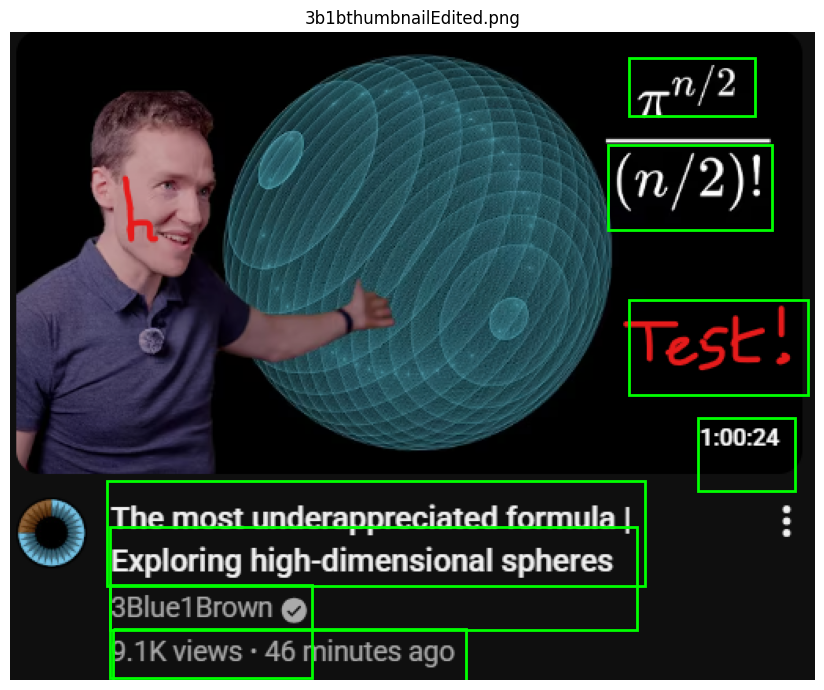

Image1.png                           |  14 region(s)  |  2273.4 ms


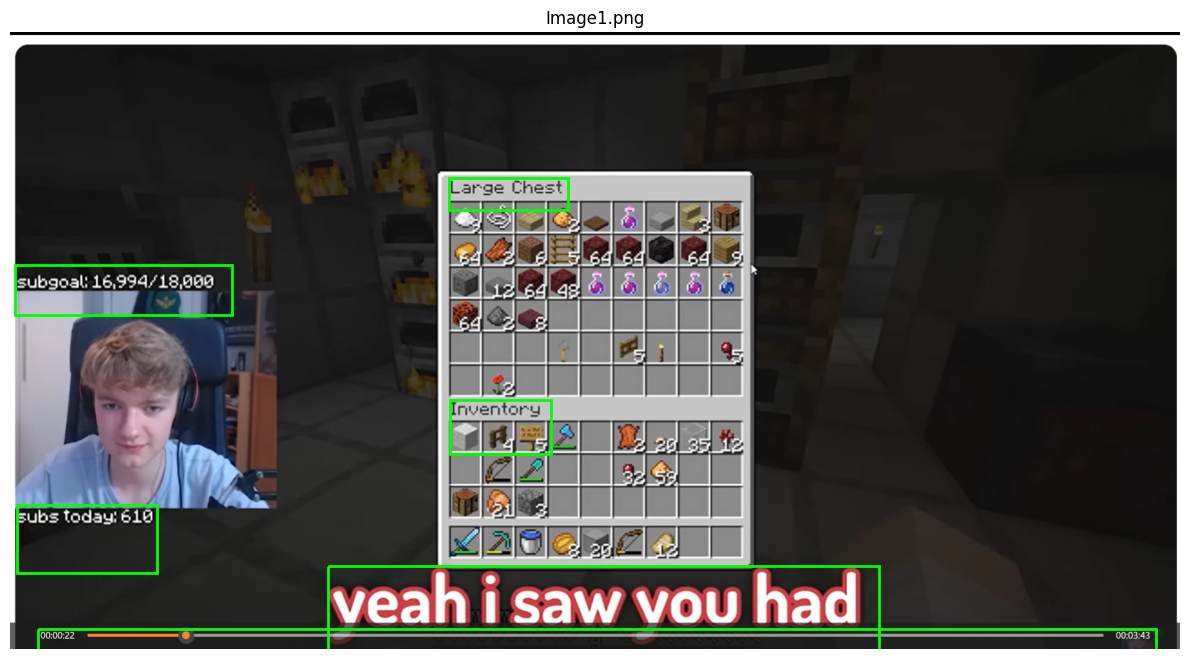

Image2.png                           |   9 region(s)  |  3158.5 ms


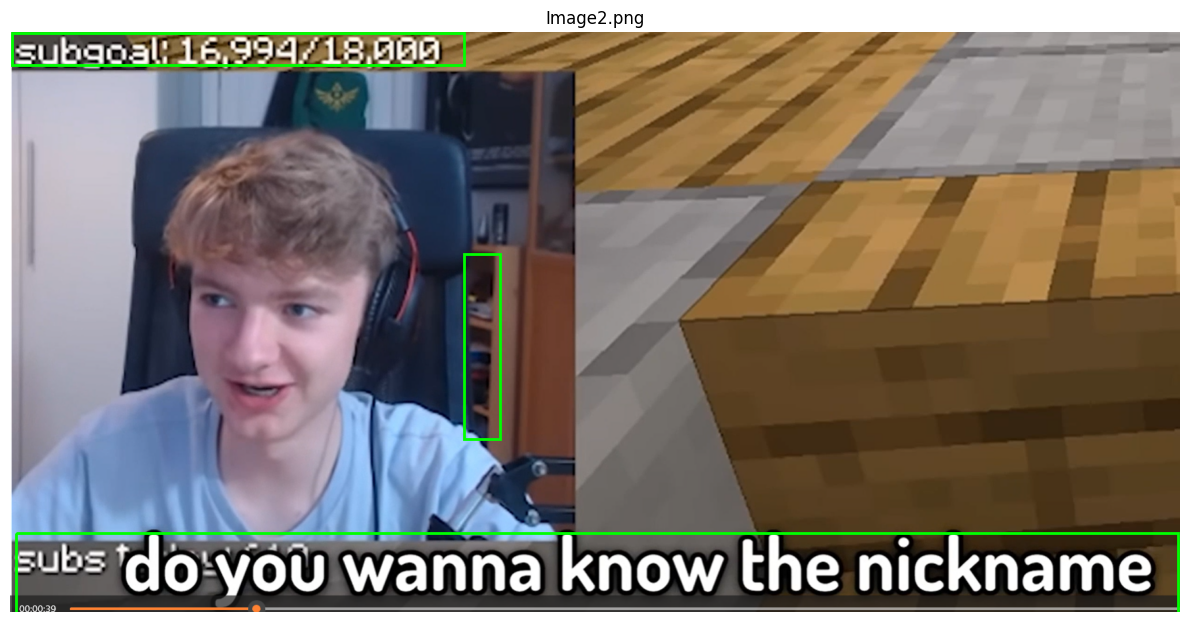

Image3.png                           |  16 region(s)  |  1310.7 ms


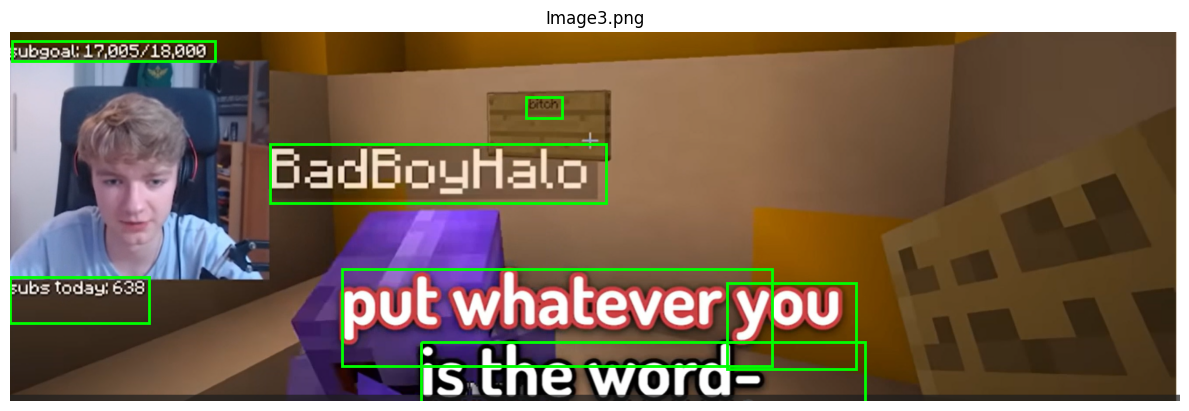


Average inference time : 1803.6 ms per image
Equivalent speed       : 0.6 frames/sec (at this resolution)


In [26]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_east_detections(image_bgr, boxes, confidences, title="EAST Detections"):
    """Draw bounding boxes returned by EAST on the image and display it."""
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(1, 1, figsize=(12, 7))
    ax.imshow(image_rgb)
    ax.set_title(title)
    ax.axis("off")

    boxes = merge_rectangles_by_y(boxes, scale_factor=1.1)

    for (x, y, w, h) in boxes:
        rect = patches.Rectangle(
            (x, y), w, h,
            linewidth=2, edgecolor="lime", facecolor="none",
        )
        ax.add_patch(rect)

    plt.tight_layout()
    plt.show()
    return fig


def benchmark_east_on_images(image_paths, net, min_confidence=0.5):
    """Run EAST on a list of images, print timing, and display detections."""
    all_times = []

    for path in image_paths:
        image = cv2.imread(path)
        if image is None:
            print(f"⚠  Could not load {path}, skipping.")
            continue

        boxes, confs, t = east_detect(image, net, min_confidence=min_confidence)
        all_times.append(t)

        print(f"{os.path.basename(path):35s}  |  {len(boxes):2d} region(s)  |  {t*1000:.1f} ms")
        draw_east_detections(image, boxes, confs, title=os.path.basename(path))

    if all_times:
        avg = sum(all_times) / len(all_times)
        print(f"\nAverage inference time : {avg*1000:.1f} ms per image")
        print(f"Equivalent speed       : {1/avg:.1f} frames/sec (at this resolution)")


# Test on all available sample images
sample_paths = [
    "../data/samples/3b1bthumbnailEdited.png",
    "../data/samples/Image1.png",
    "../data/samples/Image2.png",
    "../data/samples/Image3.png",
]

benchmark_east_on_images(sample_paths, east_net)


In [ ]:

def benchmark_east_on_video(video_path, net, duration_sec, min_confidence=0.5):
    """
    Run EAST on every frame of a video clip and report throughput.
    Returns the ratio: (total EAST inference time) / (clip length in seconds).
    A ratio < 1.0 means EAST can keep up with real-time playback.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Could not open video: {video_path}")
        return

    fps = cap.get(cv2.CAP_PROP_FPS)
    max_frames = int(fps * duration_sec)
    print(f"Video FPS: {fps:.1f}  |  Analysing {max_frames} frames ({duration_sec}s clip)")

    inference_times = []
    frames_with_text = 0

    for _ in range(max_frames):
        ret, frame = cap.read()
        if not ret:
            break
        boxes, _, t = east_detect(frame, net, min_confidence=min_confidence)
        inference_times.append(t)
        if boxes:
            frames_with_text += 1

    cap.release()

    if not inference_times:
        print("No frames processed.")
        return

    total_east_time = sum(inference_times)
    avg_ms = (total_east_time / len(inference_times)) * 1000
    ratio = total_east_time / duration_sec

    print(f"\nFrames processed        : {len(inference_times)}")
    print(f"Frames with text        : {frames_with_text} ({100*frames_with_text/len(inference_times):.1f}%)")
    print(f"Average inference time  : {avg_ms:.1f} ms / frame")
    print(f"Total EAST time         : {total_east_time:.2f}s for {duration_sec}s of footage")
    print(f"EAST time / footage time: {ratio:.3f}x  ({'✓ real-time capable' if ratio < 1 else '✗ slower than real-time'})")


# Only run if the example video exists
video_path = "../data/raw/example1.mp4"
if os.path.exists(video_path):
    benchmark_east_on_video(video_path, east_net, duration_sec=1.0)
else:
    print(f"Video not found at {video_path!r} — skipping video benchmark.")
    print("Place a video at that path and re-run this cell.")


Video FPS: 30.0  |  Analysing 90 frames (3.0s clip)

Frames processed        : 90
Frames with text        : 89 (98.9%)
Average inference time  : 949.0 ms / frame
Total EAST time         : 85.41s for 3.0s of footage
EAST time / footage time: 28.469x  (✗ slower than real-time)
